In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Create a Python function sigmoid(x) that takes a numeric input and returns the sigmoid value using the formula 1 / (1 + exp(-x)). Test your function with x = -2, 0, and 3.


In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [4]:
print("x = -2 :", sigmoid(-2))
print("x =  0 :", sigmoid(0))
print("x =  3 :", sigmoid(3))

x = -2 : 0.11920292202211755
x =  0 : 0.5
x =  3 : 0.9525741268224334


# 2. Given a dataset of 10 Instagram posts with features 'likes' and 'has_caption' (1 if caption present, 0 if not), and a label 'viral' (1 if post went viral, 0 otherwise), write code to fit a logistic regression model to predict 'viral' using scikit-learn. Print the model coefficients.

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
data = {
    'likes': [150, 2000, 300, 5000, 120, 4500, 800, 250, 6000, 900],
    'has_caption': [1, 1, 0, 1, 0, 1, 1, 0, 1, 1],
    'viral': [0, 1, 0, 1, 0, 1, 0, 0, 1, 1]
}

In [7]:
df = pd.DataFrame(data)
df.head()

,likes,has_caption,viral
0,150,1,0
1,2000,1,1
2,300,0,0
3,5000,1,1
4,120,0,0


In [8]:
X = df[['likes', 'has_caption']]
y = df['viral']

In [9]:
model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
print("Coefficient for Likes       :", model.coef_[0][0])
print("Coefficient for Has_Caption :", model.coef_[0][1])
print("Intercept                   :", model.intercept_[0])

Coefficient for Likes       : 0.1324985307158945
Coefficient for Has_Caption : 9.822576867291025e-06
Intercept                   : -112.62387763050519


Coefficient for Likes (0.1325): This is a positive number, which tells us that as the number of likes increases, the probability of the post going viral also increases. It shows that likes is a strong positive driver for virality.  

Coefficient for Has_Caption (0.0000098): This value is written in scientific notation (e-06), which means it is an incredibly tiny number close to absolute zero. It tells us that whether a post has a caption or not makes almost zero difference to the model when predicting if it goes viral.  

Intercept (-112.62): This is the baseline starting point of the model when the features are zero. Because it is a massive negative number, it tells us that if a post has 0 likes and no caption, its starting probability of going viral is basically $0\%$.   

# 3. Plot the sigmoid function for x values from -10 to 10 using matplotlib, and visually indicate the threshold at 0.5 on the plot.<br><br><em><strong>Hint:</strong> Use plt.axhline() to draw the threshold line.</em>

In [11]:
x_values = np.linspace(-10, 10, 100)
y_values = 1 / (1 + np.exp(-x_values))

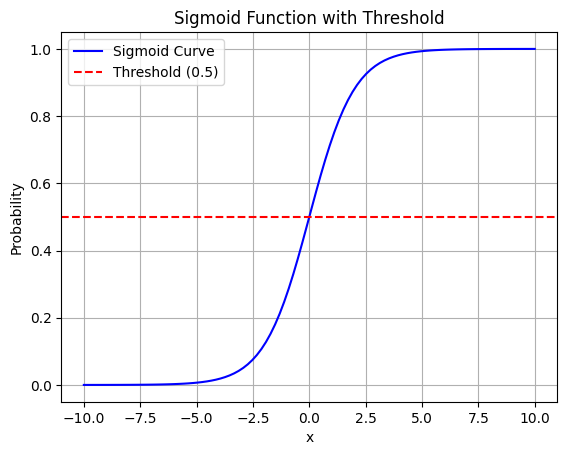

In [12]:
plt.plot(x_values, y_values, color='blue', label='Sigmoid Curve')

plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')

plt.title('Sigmoid Function with Threshold')
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)

plt.show()

# 4. Given a probability output from your logistic regression model, write a function that classifies the result as 'Viral' or 'Not Viral' based on a threshold value that you can set (default 0.5). Test your function with probabilities 0.2, 0.6, and 0.8 and thresholds 0.5 and 0.7.

In [13]:
def classify_probability(prob, threshold=0.5):
    if prob >= threshold:
        return 'Viral'
    else:
        return 'Not Viral'

In [14]:
probabilities = [0.2, 0.6, 0.8]

In [19]:
print("Threshold = 0.5")
for p in probabilities:
    result = classify_probability(p, threshold=0.5)
    print(f"Probability: {p}  result: {result}")

print("\nThreshold = 0.7")
for p in probabilities:
    result = classify_probability(p, threshold=0.7)
    print(f"Probability: {p}  result: {result}")

Threshold = 0.5
Probability: 0.2  result: Not Viral
Probability: 0.6  result: Viral
Probability: 0.8  result: Viral

Threshold = 0.7
Probability: 0.2  result: Not Viral
Probability: 0.6  result: Not Viral
Probability: 0.8  result: Viral
